## New and improved float trajectories 2019-2020 (figure 1b)

In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy

from importlib import reload
import SO_tools as tools; reload(tools)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SO_tools' from '/Users/lilah/Documents/IBIS_Project/SO_tools.py'>

In [33]:
df = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')
df_old = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_School_Year/old_AAR_BGC_extended_region_alltime.csv')

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_7258/228741287.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv')
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_7258/228741287.py:2: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_old = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_School_Year/old_AAR_BGC_extended_region_alltime.csv')


In [36]:
df_old

# NEW DATA

#convert to datetime
df_old['DATE'] = pd.to_datetime(df_old['DATE'],format = 'mixed',utc=True)
df_old = df_old.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon 

#fix lat lon values with '--' (replace with nan) 
df_old['LATITUDE'] = pd.to_numeric(df_old['LATITUDE'], errors='coerce')
df_old['LONGITUDE'] = pd.to_numeric(df_old['LONGITUDE'], errors='coerce')


In [37]:
#create season columns
df_old["year"] = df_old["DATE"].dt.year.astype("Int64")
df_old["month"] = df_old["DATE"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

df_old["season"] = df_old.apply(assign_season, axis=1)

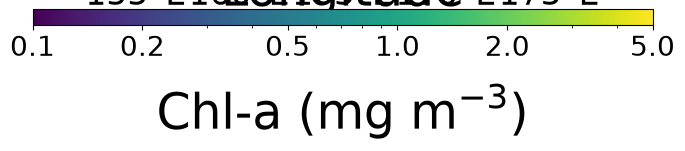

In [9]:
# things to fix: colorbar obviously, also how to make it just surface chla concentrations not the whole profile depth


fig = plt.figure(figsize=(8, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN, color = 'powderblue')
    
sc = ax.scatter(df['LONGITUDE'], df['LATITUDE'],c=df['CHLA_ADJUSTED'],
        cmap='viridis',s=300,transform=ccrs.PlateCarree(),norm=LogNorm(vmin=0.1, vmax=5), edgecolor='k', linewidth=0.1)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04, aspect =40)
cbar.set_label('Chl-a (mg m$^{-3}$)', labelpad=15, fontsize = 35)
cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
cbar.formatter = FormatStrFormatter("%.1f")
cbar.ax.tick_params(labelsize=20) 
cbar.update_ticks()

# Define start and end points for KR1 and KR2
start_lon1, start_lat1 = 151.33, -60.24
end_lon1, end_lat1 = 153.08, -59.89
start_lon2, start_lat2 = 156.12, -62.91
end_lon2, end_lat2 = 160.48, -61.66

# Plot diagonal line on map
ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=8, linestyle='-', transform=ccrs.PlateCarree())
ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=8, linestyle='-', transform=ccrs.PlateCarree())

ax.set_extent([150, 180, -68, -58], crs=ccrs.PlateCarree()) # just data region

lat = [-63.164055, -62.79286]
lon = [163.932868, 169.976922]
gl =ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 24, 'color': 'black'}
gl.ylabel_style = {'size': 24, 'color': 'black'}
ax.set_title('Float Trajectories 2013-2025', fontsize=60)

ax.text(0.5, -0.16, 'Longitude', transform=ax.transAxes, ha='center', fontsize =35)
ax.text(-0.1, 0.4, 'Latitude', transform=ax.transAxes, ha='center', rotation=90,  fontsize =35)

# cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.03)
# cbar.set_label('Chl-a (mg m$^{-3}$)', labelpad=15)
# cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
# cbar.formatter = FormatStrFormatter("%.1f")
# cbar.update_ticks()

plt.show()

# fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures_Summer/float_traj_2019_2020.png', transparent=True, bbox_inches='tight')

In [19]:
df_subset = df[df['season'].isin(['2019-2020'])]
df_subset

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
56491,56491,56491,1901155,316,A,2019-09-08 04:51:06.000013+00:00,1,-49.650000,-42.156000,1,...,NaN,2019,9,2019-2020,34.108305,2.750880,1027.089639,27.068525,0.000005,89.799995
56492,56492,56492,1901155,316,A,2019-09-08 04:51:06.000013+00:00,1,-49.650000,-42.156000,1,...,NaN,2019,9,2019-2020,34.108309,2.751532,1027.118203,27.068471,0.000005,89.799995
56493,56493,56493,1901155,316,A,2019-09-08 04:51:06.000013+00:00,1,-49.650000,-42.156000,1,...,NaN,2019,9,2019-2020,34.108335,2.750995,1027.162361,27.068538,0.000008,89.799995
56494,56494,56494,1901155,316,A,2019-09-08 04:51:06.000013+00:00,1,-49.650000,-42.156000,1,...,NaN,2019,9,2019-2020,34.106877,2.750411,1027.210027,27.067432,0.000013,89.799995
56495,56495,56495,1901155,316,A,2019-09-08 04:51:06.000013+00:00,1,-49.650000,-42.156000,1,...,NaN,2019,9,2019-2020,34.111077,2.643821,1027.268600,27.079939,0.000003,89.799995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6329676,6329676,6329676,6903777,8,A,2020-04-30 05:54:30+00:00,1,-60.442913,0.628137,1,...,NaN,2020,4,2019-2020,34.831667,-0.238408,1037.130298,27.851789,1178.290000,0.070000
6329677,6329677,6329677,6903777,8,A,2020-04-30 05:54:30+00:00,1,-60.442913,0.628137,1,...,NaN,2020,4,2019-2020,34.830672,-0.248929,1037.247749,27.851518,1180.290000,0.070000
6329678,6329678,6329678,6903777,8,A,2020-04-30 05:54:30+00:00,1,-60.442913,0.628137,1,...,NaN,2020,4,2019-2020,34.830662,-0.249023,1037.248800,27.851514,1182.290000,0.070000
6329679,6329679,6329679,6903777,8,A,2020-04-30 05:54:30+00:00,1,-60.442913,0.628137,1,...,NaN,2020,4,2019-2020,34.830662,-0.252769,1037.305609,27.851702,1184.240050,0.070000


In [39]:
df_subset_old = df_old[df_old['season'].isin(['2019-2020'])]
df_subset_old

,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,PRES,...,NITRATE_ADJUSTED_QC,NITRATE_ADJUSTED_ERROR,PH_IN_SITU_TOTAL,PH_IN_SITU_TOTAL_QC,PH_IN_SITU_TOTAL_ADJUSTED,PH_IN_SITU_TOTAL_ADJUSTED_QC,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season
90444,90444,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,112.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,9,2019-2020
90445,90445,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,112.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,9,2019-2020
90446,90446,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,117.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,9,2019-2020
90447,90447,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,117.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,9,2019-2020
90448,90448,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,122.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,9,2019-2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495113,1495113,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,1937.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,4,2019-2020
1495114,1495114,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,1962.77,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,4,2019-2020
1495115,1495115,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,1963.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,4,2019-2020
1495116,1495116,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,1988.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,4,2019-2020


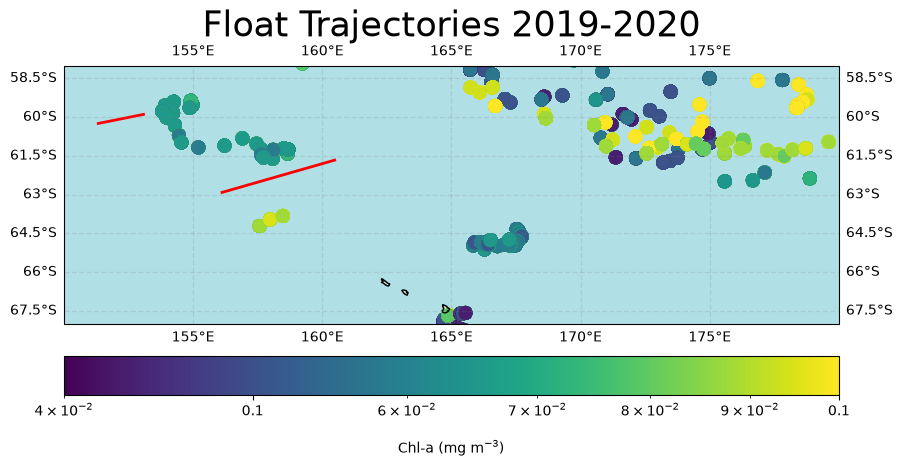

In [49]:


fig = plt.figure(figsize=(10, 14))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN, color = 'powderblue')

sc = ax.scatter(df_subset['LONGITUDE'], df_subset['LATITUDE'], c=df_subset['CHLA'], cmap='viridis', norm=LogNorm(vmin=0.04, vmax=0.1),linewidth=0.1, s=100)

# Define start and end points for KR1 and KR2
start_lon1, start_lat1 = 151.33, -60.24
end_lon1, end_lat1 = 153.08, -59.89
start_lon2, start_lat2 = 156.12, -62.91
end_lon2, end_lat2 = 160.48, -61.66

# Plot diagonal line on map
ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=2, linestyle='-', transform=ccrs.PlateCarree())
ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=2, linestyle='-', transform=ccrs.PlateCarree())

ax.set_extent([150, 180, -58, -68], crs=ccrs.PlateCarree()) # just data region

lat = [-63.164055, -62.79286]
lon = [163.932868, 169.976922]
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.2, linestyle='--')

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.03)
cbar.set_label('Chl-a (mg m$^{-3}$)', labelpad=15)
cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
cbar.formatter = FormatStrFormatter("%.1f")
cbar.update_ticks()

ax.set_title('Float Trajectories 2019-2020', fontsize = 25)

plt.show()

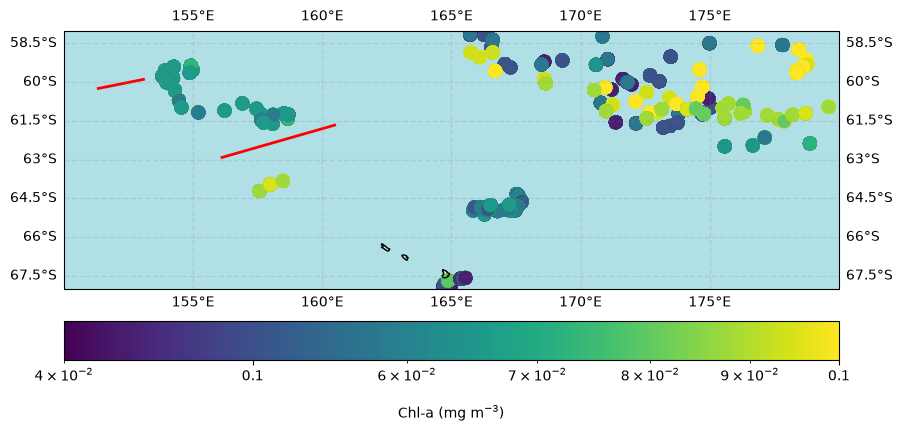

In [48]:
## OLD DATA TO COMPARE CHLA MIN AND MAX

fig = plt.figure(figsize=(10, 14))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN, color = 'powderblue')

sc = ax.scatter(df_subset_old['LONGITUDE'], df_subset_old['LATITUDE'], c=df_subset_old['CHLA'], cmap='viridis', norm=LogNorm(vmin=0.04, vmax=0.1),linewidth=0.1, s=100)

# for whatever float we end up using to highlight the trajectory with pink
# sc1 = ax.scatter(df['LONGITUDE'], df['LATITUDE'],c='magenta',
#         s=50,transform=ccrs.PlateCarree())

# Define start and end points for KR1 and KR2
start_lon1, start_lat1 = 151.33, -60.24
end_lon1, end_lat1 = 153.08, -59.89
start_lon2, start_lat2 = 156.12, -62.91
end_lon2, end_lat2 = 160.48, -61.66

# Plot diagonal line on map
ax.plot([start_lon1, end_lon1], [start_lat1, end_lat1], color='red', linewidth=2, linestyle='-', transform=ccrs.PlateCarree())
ax.plot([start_lon2, end_lon2], [start_lat2, end_lat2],color='red', linewidth=2, linestyle='-', transform=ccrs.PlateCarree())

ax.set_extent([150, 180, -58, -68], crs=ccrs.PlateCarree()) # just data region

lat = [-63.164055, -62.79286]
lon = [163.932868, 169.976922]
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.2, linestyle='--')

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.03)
cbar.set_label('Chl-a (mg m$^{-3}$)', labelpad=15)
cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
cbar.formatter = FormatStrFormatter("%.1f")
cbar.update_ticks()

plt.show()

In [12]:
df['CHLA_ADJUSTED'].max

<bound method Series.max of 0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
             ...   
6484485   -0.000009
6484486    0.002540
6484487    0.001265
6484488    0.001690
6484489    0.000416
Name: CHLA_ADJUSTED, Length: 6484490, dtype: float64>

## to do:
- subset dataframe to 2019-2020 DONE
- fix colorbar
- fix black rings where profiles aren't DONE
- widen lat + lon DONE